# Heart Disease Classification

In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("import success")

import success


In [2]:
df = pd.read_csv('heart disease classification dataset.csv')
df = df.drop(df.columns[0], axis=1)
df['sex'] = np.where(df['sex'] == "male", 1, 0)
df['target'] = np.where(df['target'] == "yes", 1, 0)
df = df.dropna()
df = pd.get_dummies(df, columns=["cp"], drop_first=True, prefix="cp")
df.head(10)

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_1,cp_2,cp_3
0,63,1,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1,False,False,True
1,37,1,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1,False,True,False
2,41,0,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1,True,False,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1,True,False,False
5,57,1,140.0,192.0,0,1,148.0,0,0.4,1,0,1,1,False,False,False
6,56,0,140.0,294.0,0,0,153.0,0,1.3,1,0,2,1,True,False,False
7,44,1,120.0,263.0,0,1,173.0,0,0.0,2,0,3,1,True,False,False
8,52,1,172.0,199.0,1,1,162.0,0,0.5,2,0,3,1,False,True,False
9,57,1,150.0,168.0,0,1,174.0,0,1.6,2,0,2,1,False,True,False
10,54,1,140.0,239.0,0,1,160.0,0,1.2,2,0,2,1,False,False,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 302
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       293 non-null    int64  
 1   sex       293 non-null    int64  
 2   trestbps  293 non-null    float64
 3   chol      293 non-null    float64
 4   fbs       293 non-null    int64  
 5   restecg   293 non-null    int64  
 6   thalach   293 non-null    float64
 7   exang     293 non-null    int64  
 8   oldpeak   293 non-null    float64
 9   slope     293 non-null    int64  
 10  ca        293 non-null    int64  
 11  thal      293 non-null    int64  
 12  target    293 non-null    int64  
 13  cp_1      293 non-null    bool   
 14  cp_2      293 non-null    bool   
 15  cp_3      293 non-null    bool   
dtypes: bool(3), float64(4), int64(9)
memory usage: 32.9 KB


In [4]:
df["target"].value_counts()

target
1    160
0    133
Name: count, dtype: int64

In [5]:
df.describe()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000
mean,54.348123,0.689420,131.679181,246.177474,0.146758,0.518771,149.880546,0.331058,1.054266,1.392491,0.730375,2.320819,0.546075
std,9.182042,0.463523,17.658077,51.405545,0.354470,0.527162,22.638525,0.471399,1.173169,0.618946,1.029862,0.613331,0.498724
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,120.000000,211.000000,0.000000,0.000000,134.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,1.000000,167.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Exploratory Data Analysis

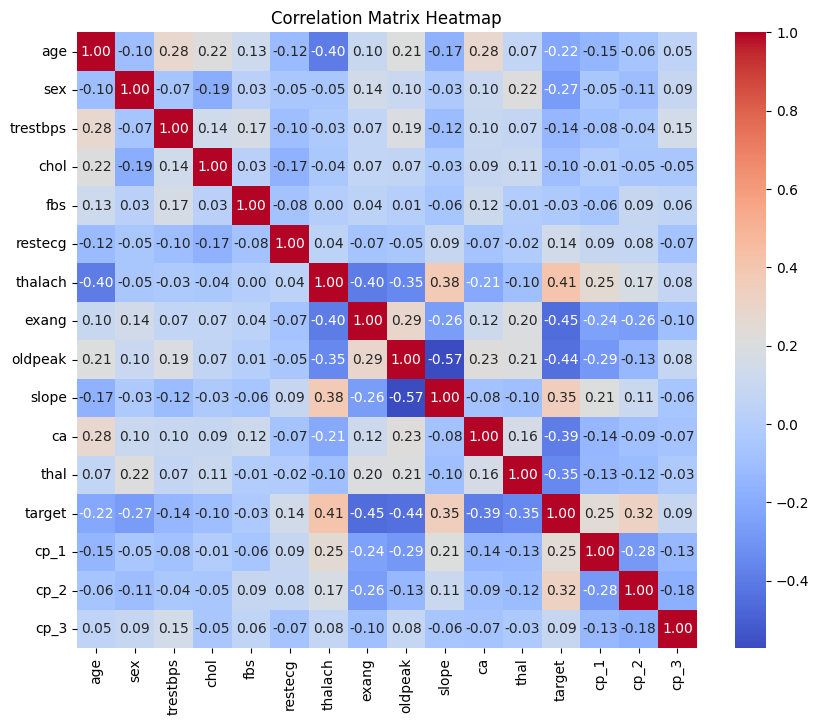

In [6]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix Heatmap")
plt.show()

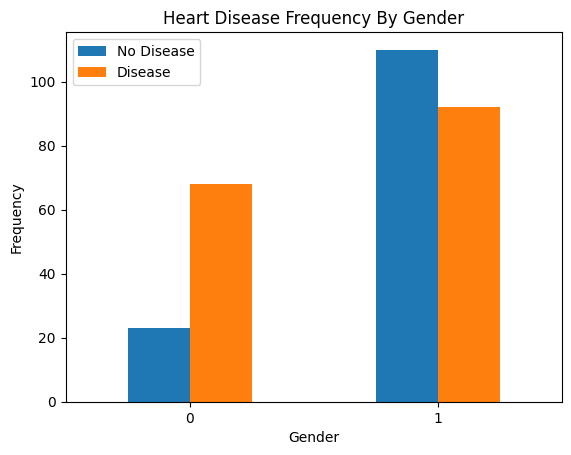

In [7]:
pd.crosstab(df['sex'], df['target']).plot(kind="bar")
plt.title("Heart Disease Frequency By Gender")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0)
plt.show()

In [8]:
df["sex"].value_counts()

sex
1    202
0     91
Name: count, dtype: int64

## Model Building

### Data Splitting

In [9]:
# import scikit-learn
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

In [10]:
X = df.drop(labels="target", axis=1)
y = df["target"].to_numpy()

In [11]:
X.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,cp_1,cp_2,cp_3
0,63,1,145.0,233.0,1,0,150.0,0,2.3,0,0,1,False,False,True
1,37,1,130.0,250.0,0,1,187.0,0,3.5,0,0,2,False,True,False
2,41,0,130.0,204.0,0,0,172.0,0,1.4,2,0,2,True,False,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,True,False,False
5,57,1,140.0,192.0,0,1,148.0,0,0.4,1,0,1,False,False,False


In [12]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [13]:
np.random.seed(42)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [14]:
print(f"Number of training points in X: {len(X_train)}")
print(f"Number of training points in Y: {len(y_train)}")
print(f"Number of testing points in X: {len(X_test)}")
print(f"Number of testing points in Y: {len(y_test)}")

Number of training points in X: 234
Number of training points in Y: 234
Number of testing points in X: 59
Number of testing points in Y: 59


### Scaling Data

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit the transformation
X_test_scaled = scaler.transform(X_test)  # use the same scaling on the test

## Logistic Regression

In [16]:
# import logistic regression
from sklearn.linear_model import LogisticRegression
print("import success")

import success


In [17]:
# initialise model
model = LogisticRegression(max_iter=1000)

# fit model
model.fit(X_train_scaled, y_train)

# get score
model.score(X_test_scaled, y_test)

0.8305084745762712

### Model Evaluation

In [18]:
# import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
print("import success")

import success


#### Confusion Matrix

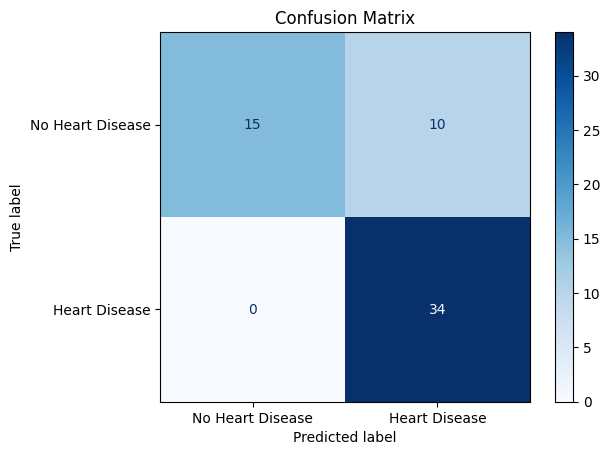

In [19]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.show()

TP: 34  
FP: 10  
TN: 15  
FN: 0

#### ROC Curve

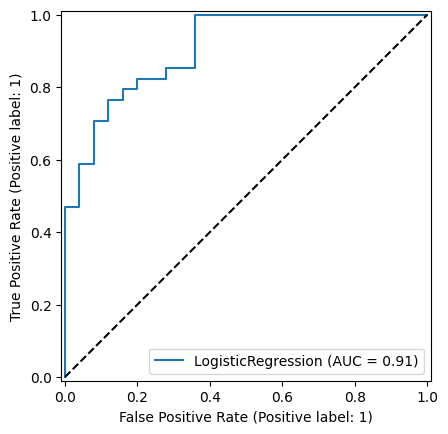

In [20]:
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.plot([0, 1], [0, 1], "k--")
plt.show()

#### Cross Validation

In [21]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

cv_results = cross_val_score(pipeline, X, y, cv=5)
print(f"All CV Accuracies: {cv_results}")
print(f"Mean CV Accuracy: {cv_results.mean():.4f}")

All CV Accuracies: [0.81355932 0.86440678 0.83050847 0.9137931  0.74137931]
Mean CV Accuracy: 0.8327


## Logistic Regression With PCA

In [22]:
# import PCA
from sklearn.decomposition import PCA
print("import success")

import success


In [23]:
pca = PCA()

X_pca = pca.fit_transform(X_test_scaled)

### Scree Plot

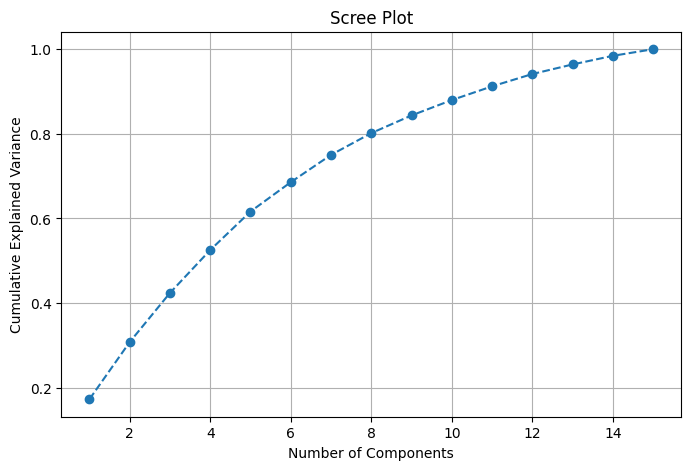

In [24]:
# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [41]:
# transform the data into 12 PCs
pca = PCA(n_components=12)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# fit model with reduced dimensions
model_pca = LogisticRegression()
model_pca.fit(X_train_pca, y_train)

# get score
print(model_pca.score(X_test_pca, y_test))

0.7966101694915254


### Model Evaluation

#### Confusion Matrix

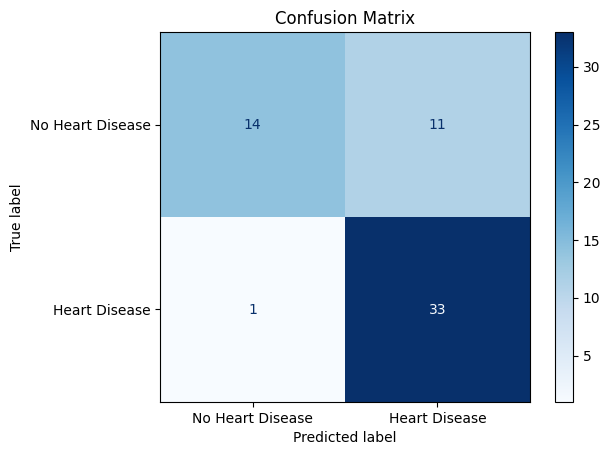

In [42]:
ConfusionMatrixDisplay.from_estimator(
    model_pca,
    X_test_pca,
    y_test,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.show()

TP: 33  
FP: 11  
TN: 14  
FN: 1

#### ROC Curve

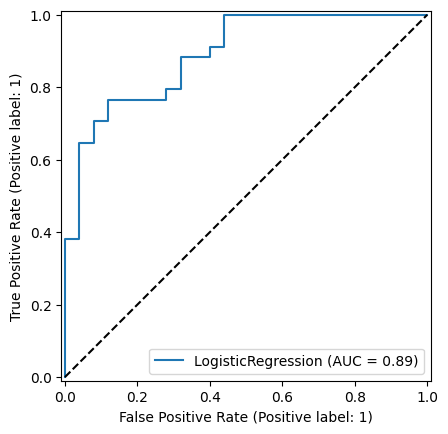

In [27]:
RocCurveDisplay.from_estimator(model_pca, X_test_pca, y_test)
plt.plot([0, 1], [0, 1], "k--")
plt.show()

#### Cross Validation

In [28]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=12)),
    ('model', LogisticRegression())
])

cv_results = cross_val_score(pipeline, X, y, cv=5)
print(f"All CV Accuracies: {cv_results}")
print(f"Mean CV Accuracy: {cv_results.mean():.4f}")

All CV Accuracies: [0.84745763 0.86440678 0.77966102 0.9137931  0.79310345]
Mean CV Accuracy: 0.8397


## Random Forest Classifier

In [29]:
# import random forest classifier
from sklearn.ensemble import RandomForestClassifier
print("import success")

import success


In [30]:
# initialise model
model = RandomForestClassifier(random_state=42)

# fit model
model.fit(X_train_scaled, y_train)

# get score
model.score(X_test_scaled, y_test)

0.8135593220338984

### Model Evaluation

#### Confusion Matrix

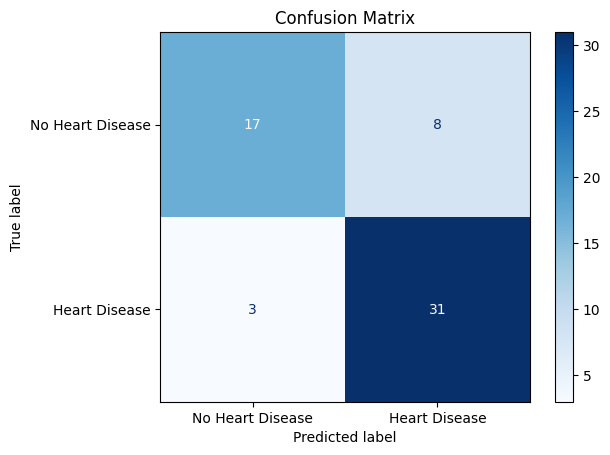

In [31]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.show()

TP: 31  
FP: 8  
TN: 17  
FN: 3

#### ROC Curve

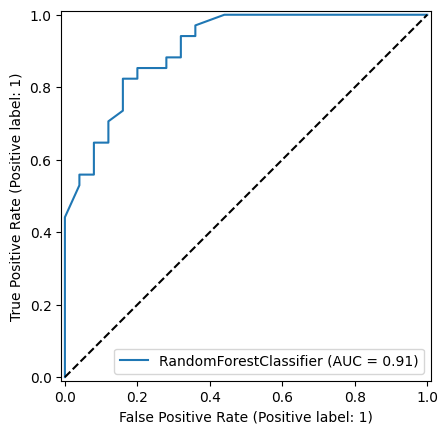

In [32]:
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.plot([0, 1], [0, 1], "k--")
plt.show()

#### Cross Validation

In [33]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

cv_results = cross_val_score(pipeline, X, y, cv=5)
print(f"All CV Accuracies: {cv_results}")
print(f"Mean CV Accuracy: {cv_results.mean():.4f}")

All CV Accuracies: [0.81355932 0.86440678 0.81355932 0.77586207 0.79310345]
Mean CV Accuracy: 0.8121


## Random Forest Classifier with Feature Selection

In [34]:
# import feature selector
from sklearn.feature_selection import SequentialFeatureSelector
print("import success")

import success


In [35]:
rf = RandomForestClassifier(random_state=42)

sfs = SequentialFeatureSelector(rf, n_features_to_select=8, direction='forward', cv=5)
sfs.fit(X_train_scaled, y_train)

# Use transform to get the reduced data
X_train_selected = sfs.transform(X_train_scaled)
X_test_selected = sfs.transform(X_test_scaled)

rf.fit(X_train_selected, y_train)
score = rf.score(X_test_selected, y_test)
print(f"Features: 8 | Accuracy: {score:.4f}")

# 1. Get the boolean mask (True for selected, False for dropped)
selected_mask = sfs.get_support()

# 2. Use the mask to filter your original column names
selected_columns = X.columns[selected_mask]

print("The selected features are:")
print(selected_columns.tolist())

Features: 8 | Accuracy: 0.8644
The selected features are:
['sex', 'restecg', 'exang', 'ca', 'thal', 'cp_1', 'cp_2', 'cp_3']


### Model Evaluation

#### Confusion Matrix

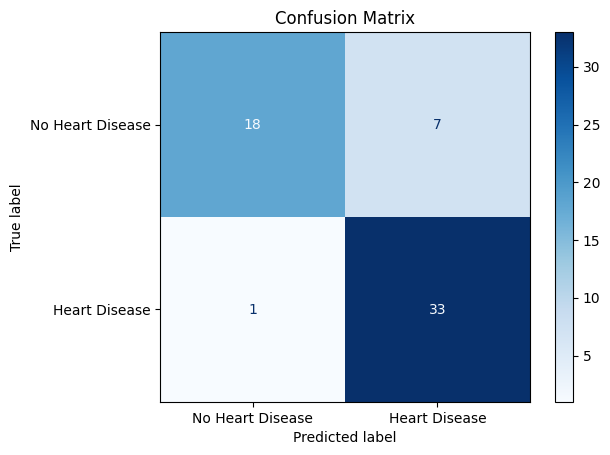

In [36]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    sfs.transform(X_test_scaled),
    y_test,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.show()

TP: 33  
FP: 7  
TN: 18  
FN: 1

#### ROC Curve

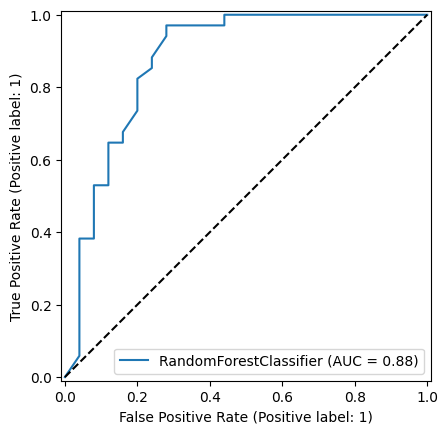

In [37]:
RocCurveDisplay.from_estimator(rf, sfs.transform(X_test_scaled), y_test)
plt.plot([0, 1], [0, 1], "k--")
plt.show()

#### Cross Validation

In [38]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

cv_results = cross_val_score(pipeline, X[['sex', 'restecg', 'exang', 'ca', 'thal', 'cp_1', 'cp_2', 'cp_3']], y, cv=5)
print(f"All CV Accuracies: {cv_results}")
print(f"Mean CV Accuracy: {cv_results.mean():.4f}")

All CV Accuracies: [0.86440678 0.86440678 0.77966102 0.75862069 0.79310345]
Mean CV Accuracy: 0.8120


## Conclusions

### Core Machine Learning Workflow

1. Data Proprocessing: Categorical variables converted into dummy variables, removal of NA and NANs.
2. Exploratory Data Analysis: Find any relations, check distributions etc.
3. Feature Scaling
4. Feature Engineering: Dimensionality reduction, selection of variables or creation of new variables
5. Choosing of Model: Different models for classification, such as logistic regression vs random forest classifier
6. Model Evaluation: Confusion matrix, ROC
7. Cross validation

### Future Improvements

1. Different features engineering
   - Create new columns by combining existing ones
   - Non-linear transformations (log or polynomial)
2. Different models
   - XGBoost
   - Neural network
3. Different hyperparameters